# Cox-Ingersoll-Ross (CIR)

A mean-reverting process that **stays positive**. It is the standard
model for an interest rate, which drifts around a long-run level but
cannot sensibly go below 0.

- `reversion_rate` -- how hard it is pulled back
- `mean` -- the level it is pulled toward
- `scale` -- how much it shakes

Those are the same three settings as `OrnsteinUhlenbeck`, because CIR
*is* an Ornstein-Uhlenbeck process with one change -- see below.

In [1]:
from symbulate import *
import matplotlib.pyplot as plt
from math import exp

## Simulate some paths

An interest rate starting at its long-run level of 5%. The dashed line
is that level. Paths wander around it, and none of them cross 0.

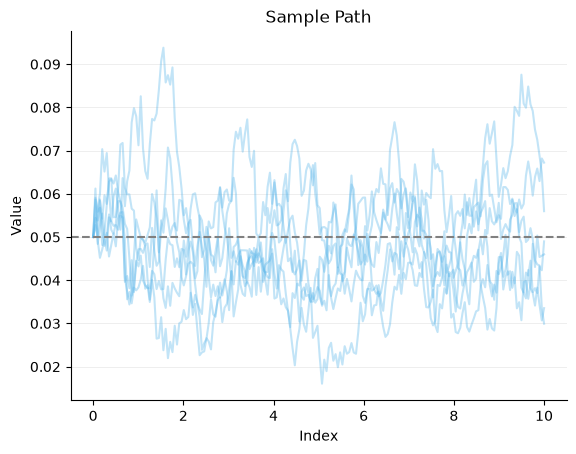

In [2]:
X = CIR(reversion_rate=1, mean=0.05, scale=0.1)

X.sim(6).plot(tmin=0, tmax=10)
plt.axhline(0.05, color="gray", linestyle="--");

## Why it cannot go negative

This is the one change from `OrnsteinUhlenbeck`. There, the jolts are
the same size wherever the process is. In CIR the jolt size is
`scale * sqrt(value)`, so it **shrinks as the value approaches 0**
while the upward pull stays. The process runs out of randomness before
it runs out of room.

Start both at 5% with the same settings and watch which one dips below
the line at 0.

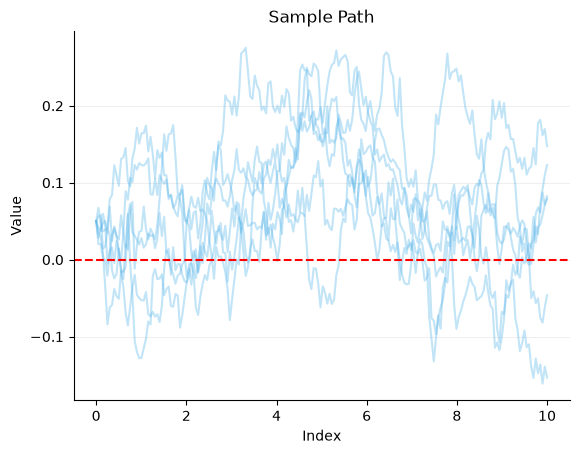

In [3]:
OrnsteinUhlenbeck(reversion_rate=1, mean=0.05, scale=0.1, initial=0.05).sim(6).plot(tmin=0, tmax=10)
plt.axhline(0, color="red", linestyle="--");

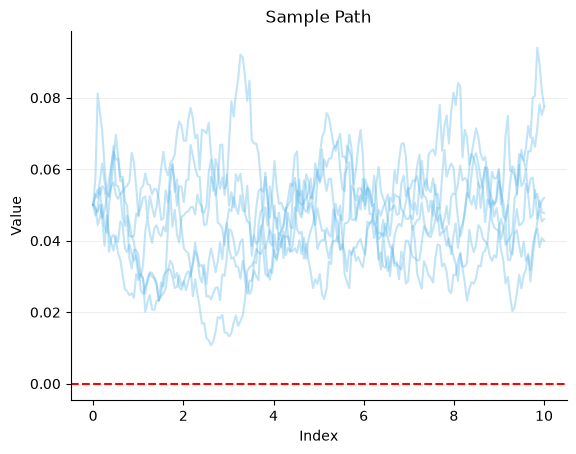

In [4]:
X.sim(6).plot(tmin=0, tmax=10)
plt.axhline(0, color="red", linestyle="--");

Counting it rather than eyeballing it -- how many rates went negative
after 3 years:

In [5]:
ou = OrnsteinUhlenbeck(reversion_rate=1, mean=0.05, scale=0.1, initial=0.05)

print(f"Ornstein-Uhlenbeck below 0:  {ou[3].sim(2000).count_lt(0)} of 2000")
print(f"CIR below 0:                 {X[3].sim(2000).count_lt(0)} of 2000")

Ornstein-Uhlenbeck below 0:  454 of 2000
CIR below 0:                 0 of 2000


## Mean reversion

Start it well below the long-run level and it climbs toward it. The
mean at time `t` is `start * decay + mean * (1 - decay)`, where
`decay = exp(-reversion_rate * t)` -- exactly the same pull an
Ornstein-Uhlenbeck process has.

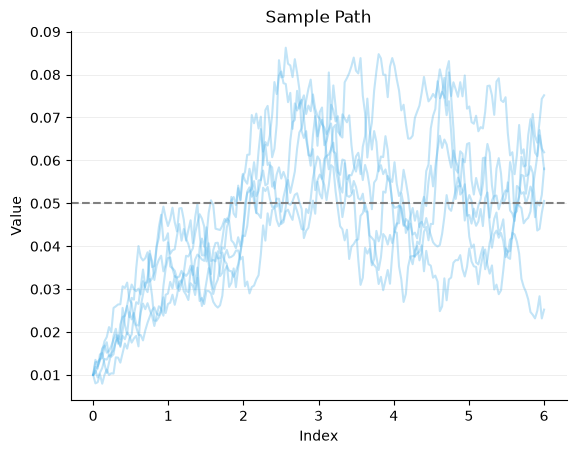

In [6]:
low = CIR(reversion_rate=1, mean=0.05, scale=0.1, initial=0.01)

low.sim(6).plot(tmin=0, tmax=6)
plt.axhline(0.05, color="gray", linestyle="--");

In [7]:
for t in [0.5, 1, 3, 10]:
    decay = exp(-1 * t)
    expected = 0.01 * decay + 0.05 * (1 - decay)
    print(f"year {t:>4}:  simulated {low[t].sim(2000).mean():.4f}   expected {expected:.4f}")

year  0.5:  simulated 0.0257   expected 0.0257
year    1:  simulated 0.0350   expected 0.0353
year    3:  simulated 0.0476   expected 0.0480
year   10:  simulated 0.0498   expected 0.0500


## Where it settles

Left alone, CIR settles into a `Gamma` distribution -- lop-sided, and
living entirely above 0, which a normal curve could never do. Its
shape is `2 * reversion_rate * mean / scale**2` and its rate is
`2 * reversion_rate / scale**2`.

Currently Showing: Histogram (Default)
Alternative Plots: Rug Plot (type = "rug"), Density Plot (type = "density"), Box Plot (type = "box"), Violin Plot (type = "violin"), ECDF Plot (type = "ecdf")


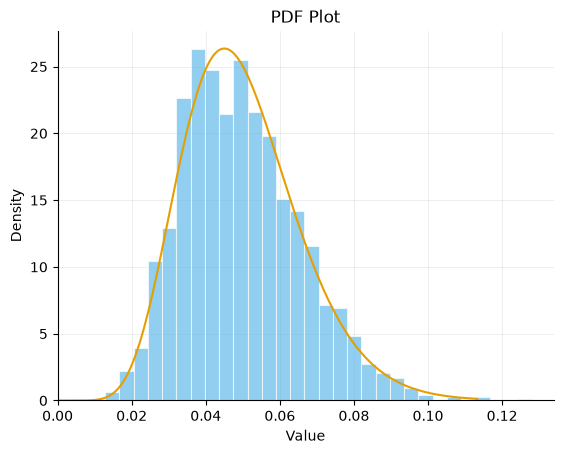

In [8]:
shape = 2 * 1 * 0.05 / 0.1**2
rate = 2 * 1 / 0.1**2

X[40].sim(2000).plot()
Gamma(shape=shape, rate=rate).plot()

The long-run mean is just `mean`, and the long-run variance is
`mean * scale**2 / (2 * reversion_rate)`:

In [9]:
settled = X[40].sim(2000)

print(f"mean:  {settled.mean():.4f}   expected 0.0500")
print(f"var:   {settled.var():.6f}   expected {0.05 * 0.1**2 / 2:.6f}")

mean:  0.0499   expected 0.0500
var:   0.000236   expected 0.000250


## Can it ever touch 0?

Only if the shaking overpowers the pull. The test is the **Feller
condition**, `2 * reversion_rate * mean >= scale**2`. When it holds the
path never reaches 0 at all; when it fails the path can touch 0, but is
pushed straight back up and never goes below.

In [10]:
calm = CIR(reversion_rate=1, mean=0.05, scale=0.1)   # 0.10 >= 0.01, holds
wild = CIR(reversion_rate=1, mean=0.02, scale=0.4)   # 0.04 <  0.16, fails

print(f"calm, smallest rate seen:  {calm[3].sim(2000).min():.2e}")
print(f"wild, smallest rate seen:  {wild[3].sim(2000).min():.2e}")

calm, smallest rate seen:  8.98e-03
wild, smallest rate seen:  6.59e-15


## Two things to know

**1. This is simulated exactly.** Unlike `DiffusionProcess`, CIR is not
built from small steps, so there is no step size to tune and no
accumulated error. Given its value now, its value at any later time
follows a known distribution -- a scaled noncentral chi-square -- so
each new time is drawn in one shot however far ahead it is. The details
are in `symbulate/diffusion_process.py`.

You can see it: jumping straight to year 5 gives the same answer as
walking there in fifty steps. An approximate scheme would drift.


In [11]:
def walk_there(path):
    """Step to year 5 in fifty small forward steps instead of one."""
    for i in range(1, 51):
        value = path(5 * i / 50)
    return value


print(f"one jump to year 5:      mean {low[5].sim(1000).mean():.4f}")
print(f"fifty steps to year 5:   mean {low.apply(walk_there).sim(1000).mean():.4f}")

one jump to year 5:      mean 0.0492
fifty steps to year 5:   mean 0.0496


**2. Asking times out of order is the one approximate corner.** A CIR
path pinned at *both* ends has no simple formula, so asking for a time
that falls between two times already computed uses an approximation.
Asking times in increasing order -- which is what plotting and `X[t]`
do -- is exact.